# Coarse Full Waveform Inversion

1. https://www.kaggle.com/competitions/waveform-inversion/code
2. https://www.kaggle.com/code/hanchenwang114/waveform-inversion-kaggle-competition-tutorial/notebook
3. https://arxiv.org/abs/2111.02926

## Imports

In [17]:
import os,sys; sys.path.append(os.getcwd().replace("fwi",""))
from util import get_torch_device_backend
from acoustic_forward_solver import acoustic_forward_solver, FWIPARAMETERS
from gauss_newton_solver import fwi_gn_solver
import chonknoris
import torch
import gpytorch
import lightning 
from matplotlib import pyplot,colors,cm
import os
import glob
import pandas as pd
import numpy as np
import timeit
import neuralop
import time 
import pyKoLesky.cholesky
import qmcpy as qp
import fastgps
import warnings

## Torch Setup

In [18]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(17)
DEVICE,TORCH_BACKEND = get_torch_device_backend(deviceidx=7)
print("DEVICE = %s"%str(DEVICE))
print("TORCH_BACKEND = %s"%str(TORCH_BACKEND.__name__))
EPS = torch.finfo(torch.get_default_dtype()).eps
EPS

DEVICE = cuda:7
TORCH_BACKEND = torch.cuda


2.220446049250313e-16

## Boilderplate

In [19]:
ROOT = "."
assert os.path.isfile(ROOT+"/fwi.ipynb")

In [20]:
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
COLORS[:3] = COLORS[:3][::-1]
LWTHICK = 3
LWTHIN = .05
HIGHLIGHTS = 4

In [21]:
def compute_l2errors(x, xhat):
    x = x.flatten(start_dim=1)
    xhat = xhat.flatten(start_dim=1) 
    diff = x-xhat
    xnorm = torch.linalg.norm(x,dim=1)
    diffnorm = torch.linalg.norm(diff,dim=1) 
    l2rerror = diffnorm/xnorm 
    return l2rerror

In [22]:
class Predictor:
    def __init__(self, pred, outputs_cls):
        self.pred = pred 
        self.outputs_cls = outputs_cls
    def forward_eval(self, xtf):
        with torch.no_grad(), torch.inference_mode(), torch.cuda.device(DEVICE):
            outputstf = self.pred(xtf)#.detach()
        y = self.outputs_cls.backwards(outputstf) 
        return y

## Load Dataset

In [23]:
pname = "RES10"
vtype = "Style_B"
tag = "NEWTRY_RELAX_1e+01"
custom_rkhs_v = False
custom_rkhs_w = False
outdir = './data/%s/%s'%(pname,vtype)
assert os.path.isdir(outdir)
p = FWIPARAMETERS[pname]
for _key,_val in p.items():
    print("p['%s'] = %s"%(_key,_val))
print()
_data_split = torch.load(outdir+"/split_train_val.pt",weights_only=True)
_data_nk = torch.load(outdir+"/NK.%s.RKHS_v_%s.RKHS_w_%s.pt"%(tag,"custom" if custom_rkhs_v else "eye","custom" if custom_rkhs_w else "eye"),weights_only=True)
data = {**_data_split,**_data_nk}
for _key,_val in data.items():
    print("data['%s'].shape = %s"%(_key,str(tuple(_val.shape))))
print()
Thetainv_v = torch.load(outdir+"/RKHS_v_%s.pt"%("custom" if custom_rkhs_v else "eye"),weights_only=True)["Thetainv"]
Thetainv_w = torch.load(outdir+"/RKHS_w_%s.pt"%("custom" if custom_rkhs_w else "eye"),weights_only=True)["Thetainv"]
print("Thetainv_v.shape = %s"%str(tuple(Thetainv_v.shape)))
print("Thetainv_w.shape = %s"%str(tuple(Thetainv_w.shape)))

p['name'] = RES10
p['nx'] = 10
p['dx'] = 10
p['nbc'] = 17
p['nt'] = 144
p['dt'] = 0.001
p['freq'] = 35
p['coord_sx'] = [1.4285714285714286, 25.0, 50.0, 75.71428571428571, 100.0]
p['coord_sz'] = [1, 1, 1, 1, 1]

data['velocity'].shape = (1000, 10, 10)
data['wavefield'].shape = (1000, 5, 143, 10)
data['velocity_train'].shape = (800, 10, 10)
data['velocity_val'].shape = (200, 10, 10)
data['wavefield_train'].shape = (800, 5, 143, 10)
data['wavefield_val'].shape = (200, 5, 143, 10)
data['tidxs'].shape = (800,)
data['vidxs'].shape = (200,)
data['vs'].shape = (1000, 401, 10, 10)
data['rmses'].shape = (1000, 401)
data['times'].shape = (401,)
data['relaxations'].shape = (1000, 401)
data['lrs'].shape = (1000, 401)
data['updated'].shape = (1000, 400)
data['Linvs'].shape = (1000, 400, 100, 100)
data['cond_nums'].shape = (1000, 400)
data['l2rerrors'].shape = (1000, 401)
data['v_true'].shape = (1000, 10, 10)
data['w_true'].shape = (1000, 5, 143, 10)

Thetainv_v.shape = (100, 100)
Thetainv_w.shape = 

In [24]:
R,Ns,Nt,Nx = data["wavefield"].shape
lti0,lti1 = torch.tril_indices(Nx**2,Nx**2)
eyeNx2 = torch.eye(Nx**2,device=DEVICE)
Nx2r = torch.arange(Nx*Nx)

## Explore Dataset

### Tables

In [25]:
print("L2 relative errors")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["l2rerrors"]).describe().T.iloc[::5])

L2 relative errors


,count,mean,std,min,25%,50%,75%,max
0,1000.0,0.081579,0.010156,6.118921e-02,7.500019e-02,7.995768e-02,8.588582e-02,0.159844
5,1000.0,0.043423,0.029523,9.157272e-03,2.819829e-02,3.625789e-02,4.780100e-02,0.374540
10,1000.0,0.016894,0.019813,1.823901e-03,1.023459e-02,1.432663e-02,1.898833e-02,0.332602
15,1000.0,0.007633,0.016043,6.320876e-05,2.814488e-03,5.602573e-03,9.098892e-03,0.297107
20,1000.0,0.002983,0.010590,2.805113e-09,9.495014e-05,1.045011e-03,3.333607e-03,0.228124
25,1000.0,0.001139,0.007180,2.663886e-14,1.221595e-08,1.362268e-06,2.350248e-04,0.158640
30,1000.0,0.000459,0.004032,2.215821e-14,3.957538e-13,6.751069e-11,4.615857e-08,0.103633
35,1000.0,0.000218,0.002397,2.230836e-14,1.335242e-13,3.518833e-13,3.191852e-12,0.056446
40,1000.0,0.000130,0.001677,2.253537e-14,1.186004e-13,2.464876e-13,6.026809e-13,0.031151
45,1000.0,0.000096,0.001382,2.253537e-14,1.159840e-13,2.296223e-13,4.895055e-13,0.027178


In [26]:
print("Relaxations")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["relaxations"]).describe().T.iloc[::5])

Relaxations


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
5,1000.0,8.115625e+00,9.188965e+00,6.250000e-01,5.000000e+00,5.000000e+00,1.000000e+01,1.600000e+02
10,1000.0,7.972266e-01,5.729550e+00,3.906250e-02,1.562500e-01,3.125000e-01,6.250000e-01,1.600000e+02
15,1000.0,1.093311e-01,1.334749e+00,2.441406e-03,1.953125e-02,1.953125e-02,3.906250e-02,4.000000e+01
20,1000.0,1.827194e-02,1.948144e-01,1.525879e-04,2.441406e-03,4.882812e-03,9.765625e-03,5.000000e+00
25,1000.0,4.739313e-03,4.857465e-02,9.536743e-06,3.051758e-04,6.103516e-04,2.441406e-03,1.250000e+00
30,1000.0,1.750522e-03,2.065136e-02,2.384186e-06,7.629395e-05,1.525879e-04,6.103516e-04,6.250000e-01
35,1000.0,2.697446e-03,1.706716e-02,1.192093e-06,7.629395e-05,3.051758e-04,1.220703e-03,3.125000e-01
40,1000.0,6.262537e-02,5.104400e-01,1.192093e-06,1.525879e-04,1.220703e-03,9.765625e-03,1.000000e+01
45,1000.0,1.973987e+00,1.633325e+01,2.980232e-07,1.220703e-03,1.953125e-02,3.125000e-01,3.200000e+02


In [27]:
print("Learning rates")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(pd.DataFrame(data["lrs"]).describe().T.iloc[::5])

Learning rates


,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
5,1000.0,1.369500e+00,4.836876e-01,5.000000e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
10,1000.0,1.706500e+00,5.783098e-01,5.000000e-01,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00
15,1000.0,1.893000e+00,7.824086e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00
20,1000.0,1.875000e+00,8.602994e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,8.000000e+00
25,1000.0,1.600500e+00,9.119931e-01,2.500000e-01,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
30,1000.0,1.092578e+00,7.506476e-01,7.812500e-03,5.000000e-01,1.000000e+00,1.000000e+00,8.000000e+00
35,1000.0,5.352114e-01,6.550543e-01,2.441406e-04,3.125000e-02,2.500000e-01,1.000000e+00,8.000000e+00
40,1000.0,2.210017e-01,6.847958e-01,7.629395e-06,1.953125e-03,1.562500e-02,1.250000e-01,1.600000e+01
45,1000.0,6.938989e-02,2.840297e-01,2.384186e-07,6.103516e-05,4.882812e-04,7.812500e-03,4.000000e+00


### Plots

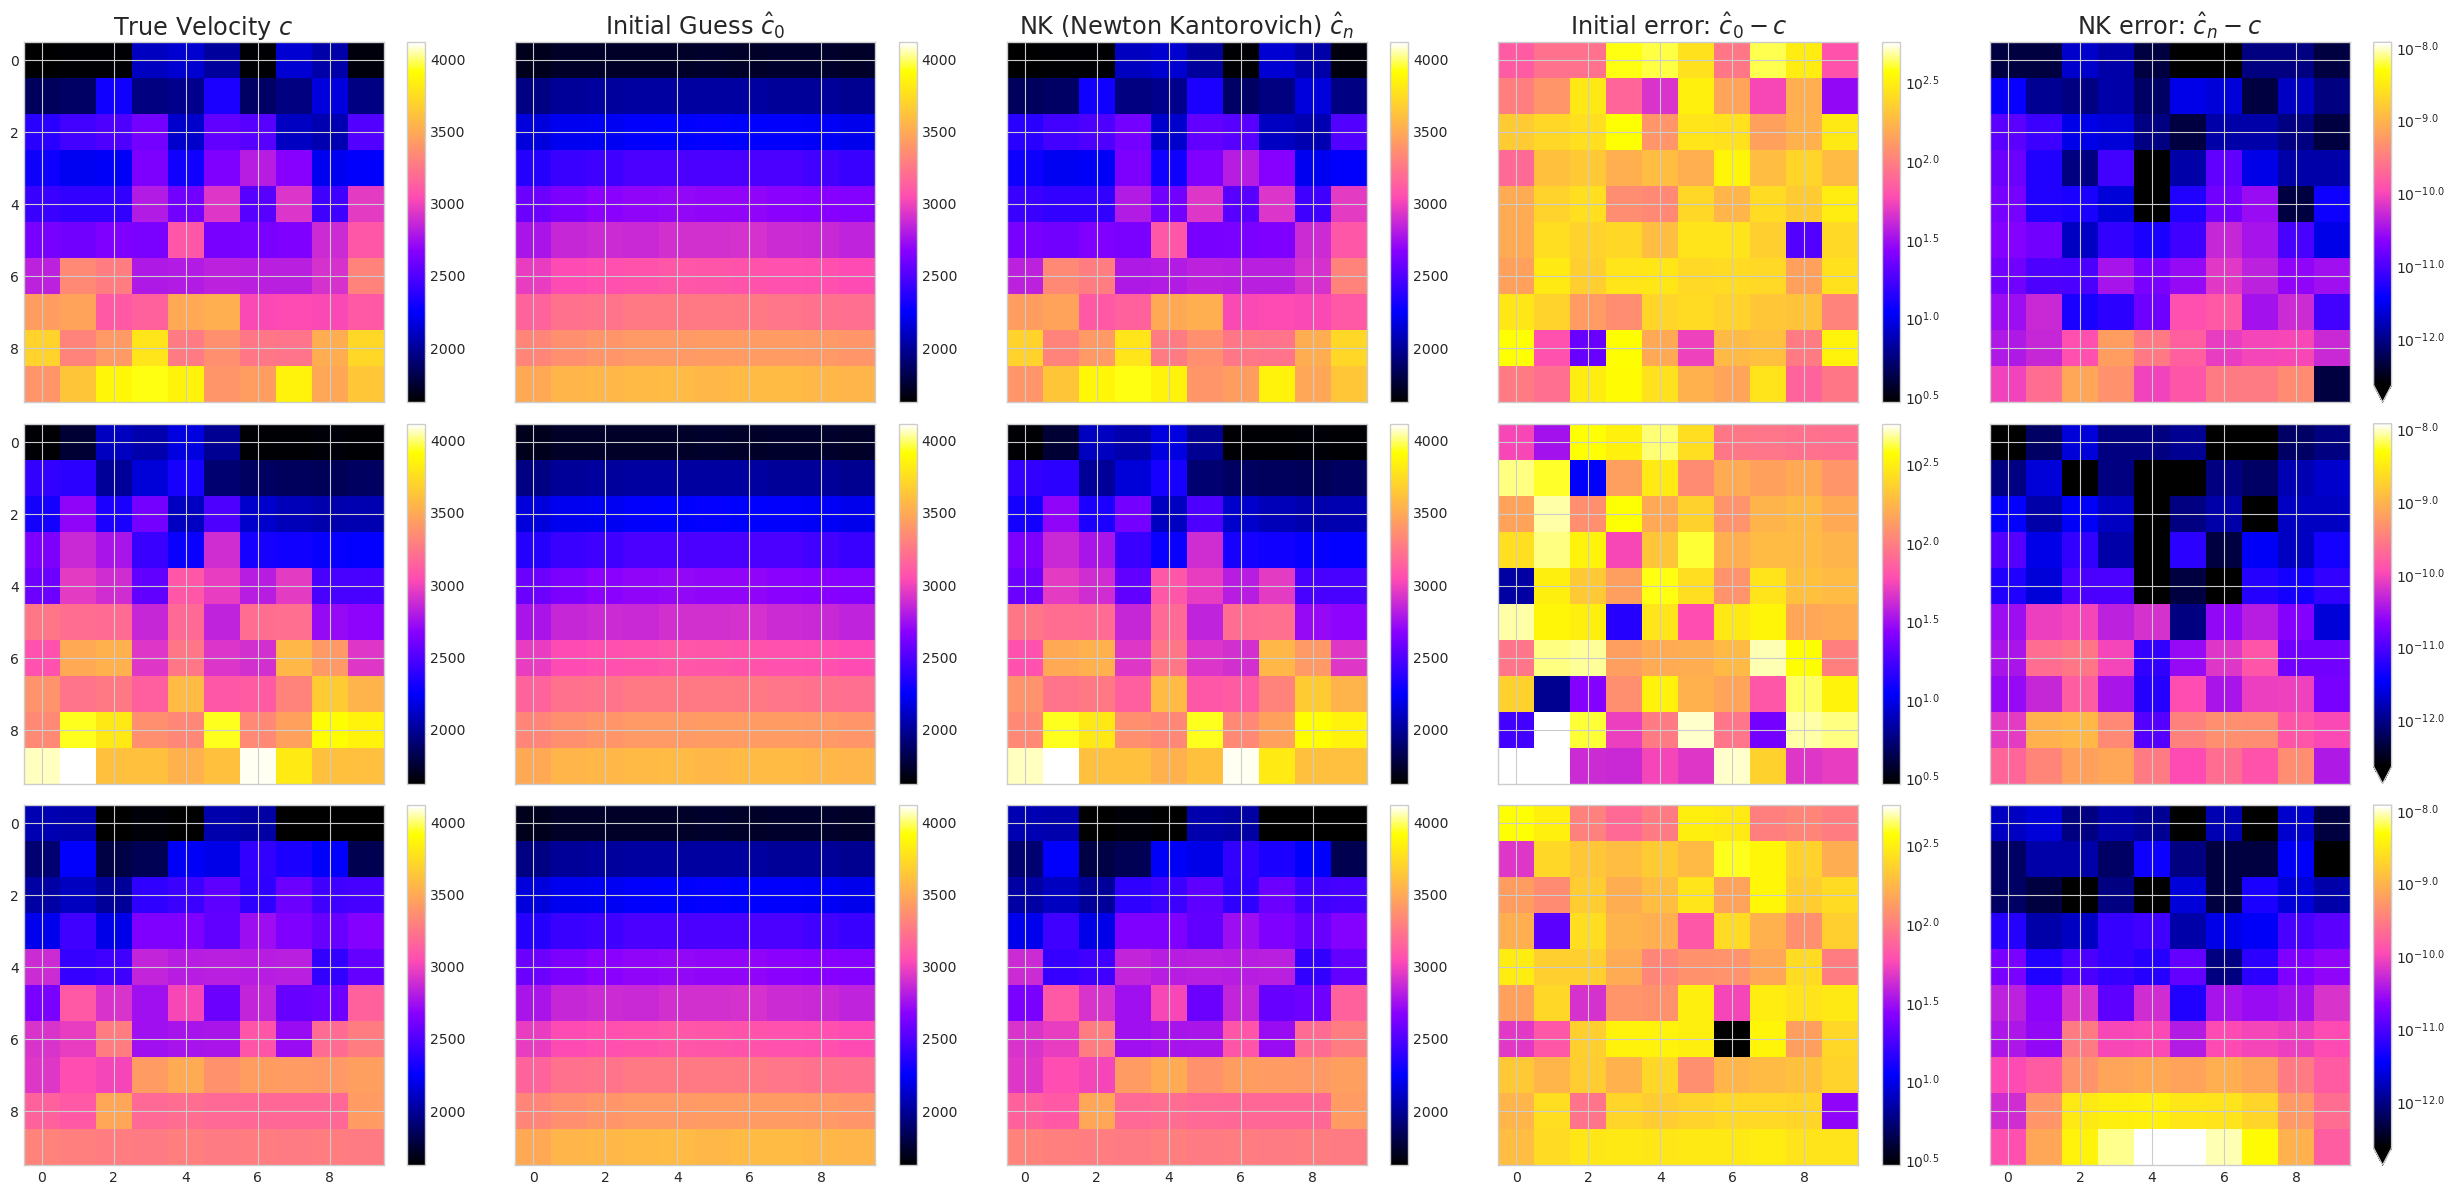

In [28]:
def plot_nk_velocities(v_true, v0, vfinal, contours=False):
    initial_error_log10 = torch.log10(torch.abs(v_true-v0))
    final_error_log10 = torch.log10(torch.abs(v_true-vfinal))
    final_error_log10[final_error_log10==-torch.inf] = final_error_log10[final_error_log10.isfinite()].min()
    _initial_error_log10_amin = initial_error_log10.min()
    _initial_error_log10_amax = initial_error_log10.max()
    _final_error_log10_amin = final_error_log10.min()
    _final_error_log10_amax = final_error_log10.max()
    _cbmin = torch.min(v_true.min(),v0.min())
    _cbmax = torch.max(v_true.max(),v0.max())
    _plot_data = [
        (v_true,r"True Velocity $c$",_cbmin,_cbmax,False,None),
        (v0,r"Initial Guess $\hat{c}_0$",_cbmin,_cbmax,False,None),
        (vfinal,r"NK (Newton Kantorovich) $\hat{c}_n$",_cbmin,_cbmax,False,None),
        (initial_error_log10,r"Initial error: $\hat{c}_0-c$",_initial_error_log10_amin,_initial_error_log10_amax,True,None),
        (final_error_log10,r"NK error: $\hat{c}_n-c$",_final_error_log10_amin,_final_error_log10_amax,True,"min"),
        ]
    nrows = _plot_data[0][0].size(0)
    ncols = len(_plot_data)
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(5*ncols,4*nrows),sharex=True,sharey=True)
    ax = ax.reshape((nrows,ncols))
    for j,(_v,name,_vmin,_vmax,log10ed,extend) in enumerate(_plot_data):
        for i in range(nrows):
            cax = ax[i,j].imshow(_v[i].cpu(),cmap="gnuplot2",vmin=_vmin if _vmin is not None else None,vmax=_vmax if _vmax is not None else None)
            cbar = fig.colorbar(cax,extend=extend)
            if log10ed:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore",UserWarning)
                    cbar.ax.set_yticklabels([r"$10^{%.1f}$"%(int(_tick) if _tick%1==0 else _tick) for _tick in cbar.ax.get_yticks()]) 
        ax[0,j].set_title(name,fontsize="xx-large")
    fig.tight_layout()
    return fig,ax 
_R = 3
fig,ax = plot_nk_velocities(data["velocity"][:_R],data["vs"][:_R,0],data["vs"][:_R,-1],contours=True)
fig.savefig(outdir+"/fwi_data.png",dpi=256)

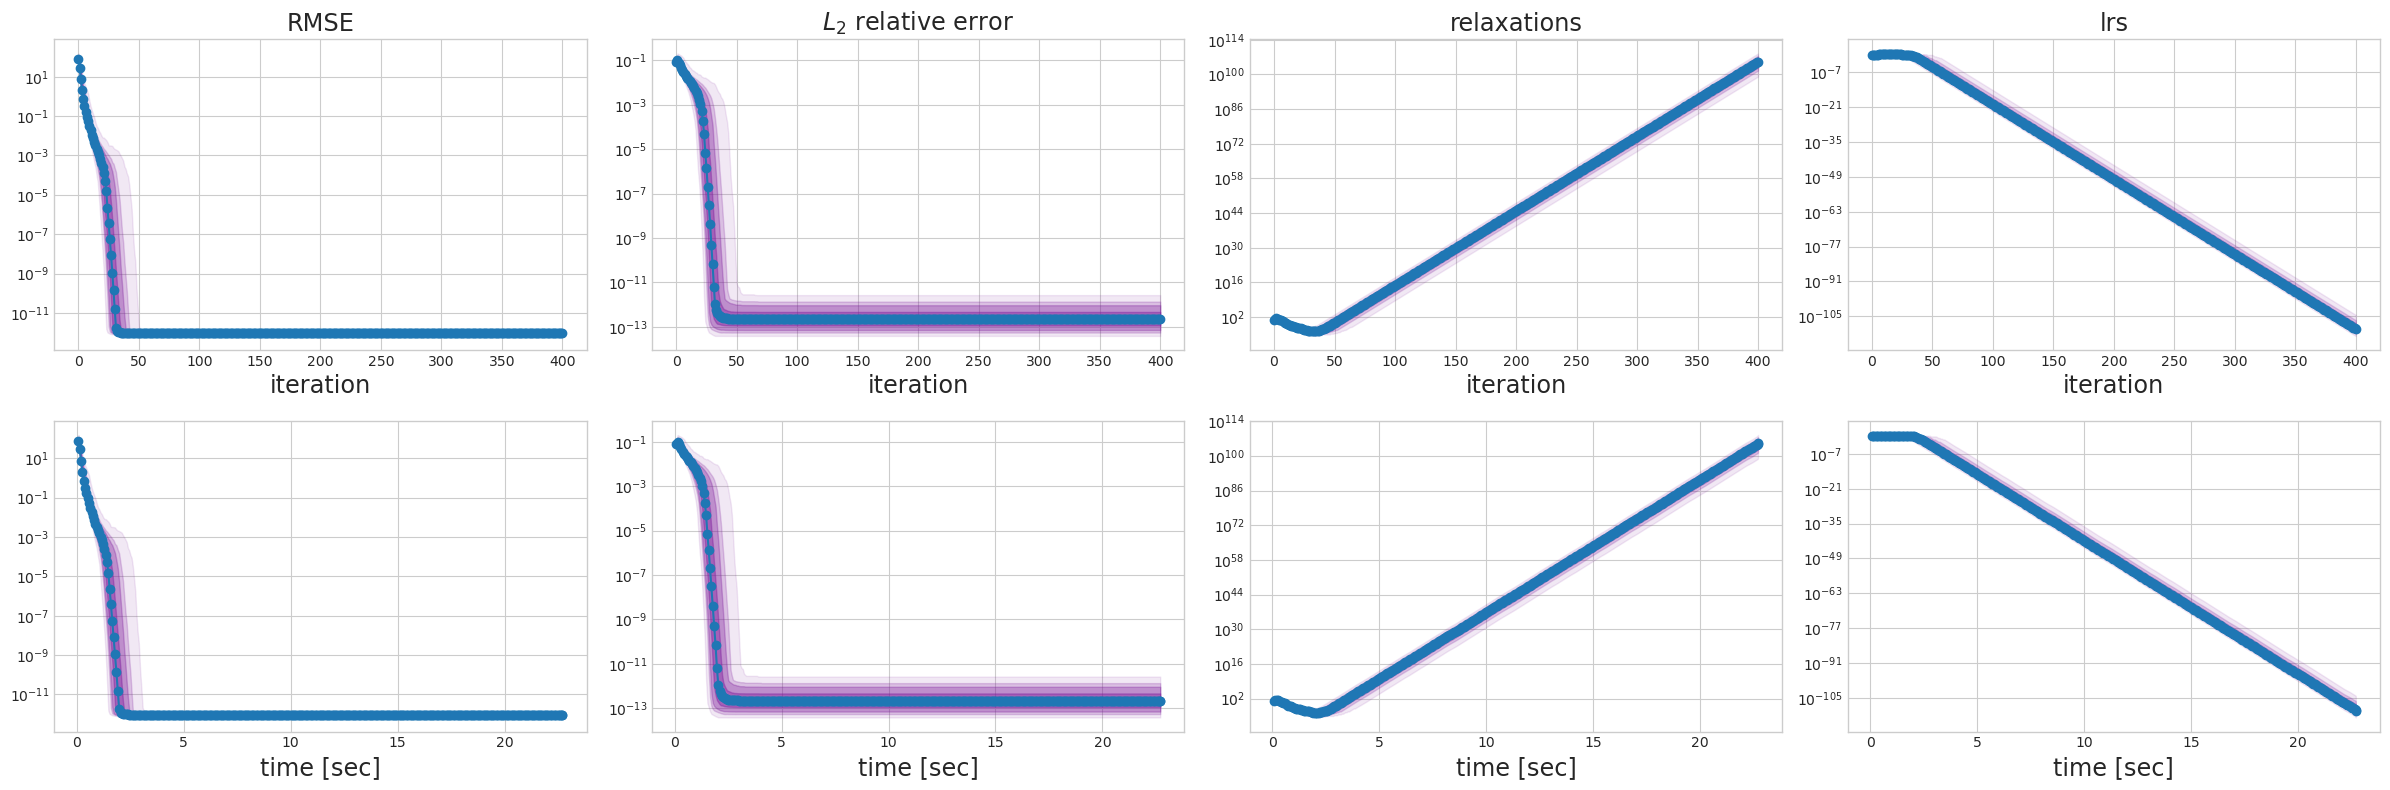

In [29]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmses"],None)],
            [(None,data["l2rerrors"],None)],
            [(None,data["relaxations"],None)],
            [(None,data["lrs"],None)],

        ],
        [
            [(data["times"].cumsum(0),data["rmses"],None)],
            [(data["times"].cumsum(0),data["l2rerrors"],None)],
            [(data["times"].cumsum(0),data["relaxations"],None)],
            [(data["times"].cumsum(0),data["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    colors = [COLORS[0]],
    ylogscale = True,
    fsx=4,fsy=6,
    legends=False)
fig.tight_layout()
fig.savefig(outdir+"/fwi_coarse_nk_convergence.pdf",bbox_inches="tight")

## Initial Guess Model

### Input Data

In [30]:
class InputDataTFIG:
    def __init__(self, w, tidxs, vidxs, normalize=False):
        self.normalize = normalize
        assert w.device==tidxs.device==vidxs.device
        self.w_t = w[tidxs]
        self.w_v = w[vidxs]
        if self.normalize:
            w_t_mean = self.w_t.mean(0)
            w_t_std = self.w_t.std(0)
            w_t_std[w_t_std==0] = 1
            self.w_t = (self.w_t-w_t_mean)/w_t_std
            self.w_v = (self.w_v-w_t_mean)/w_t_std
        self.w_t = self.w_t.flatten(start_dim=1) 
        self.w_v = self.w_v.flatten(start_dim=1) 
inputs_ig_cls = InputDataTFIG(
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True,
)
print("inputs_ig_cls.w_t.shape = %s"%str(tuple(inputs_ig_cls.w_t.shape)))
print("inputs_ig_cls.w_v.shape = %s"%str(tuple(inputs_ig_cls.w_v.shape)))

inputs_ig_cls.w_t.shape = (800, 7150)
inputs_ig_cls.w_v.shape = (200, 7150)


### Output Data

In [31]:
class OutputDataTFIG:
    def __init__(self, v, tidxs, vidxs, normalize=False, log=False):
        self.normalize = normalize
        self.log = log
        assert v.device==tidxs.device==vidxs.device
        self.nonbatch_shape = list(v.shape[1:])
        self.v_t = v[tidxs]
        self.v_v = v[vidxs]
        if self.log:
            self.v_t = torch.log(self.v_t)
            self.v_v = torch.log(self.v_v)
        if self.normalize:
            self.v_t_mean = self.v_t.mean(0)
            self.v_t_std = self.v_t.std(0).clone()
            self.v_t_std[self.v_t_std==0] = 1
            self.v_t = (self.v_t-self.v_t_mean)/self.v_t_std
            self.v_v = (self.v_v-self.v_t_mean)/self.v_t_std
        self.v_t = self.v_t.flatten(start_dim=1)
        self.v_v = self.v_v.flatten(start_dim=1)
    def backwards(self, outputs):
        outputs = outputs.reshape([-1]+list(self.nonbatch_shape))
        if self.normalize:
            outputs = outputs*self.v_t_std+self.v_t_mean
        if self.log:
            outputs = torch.exp(outputs)
        return outputs
outputs_ig_cls = OutputDataTFIG(
    data["velocity"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    normalize = True, 
    log = True,
)
print("outputs_ig_cls.v_t.shape = %s"%str(tuple(outputs_ig_cls.v_t.shape)))
print("outputs_ig_cls.v_v.shape = %s"%str(tuple(outputs_ig_cls.v_v.shape)))

outputs_ig_cls.v_t.shape = (800, 100)
outputs_ig_cls.v_v.shape = (200, 100)


### Model Prep

In [32]:
outdir_igmodels = outdir+"/MODELS_IG"
if not os.path.isdir(outdir_igmodels): os.mkdir(outdir_igmodels)

### GP

In [33]:
import gc; gc.collect()
torch.cuda.empty_cache()
sgp_ig = fastgps.StandardGP(
    qp.KernelMatern52(
        d = Ns*Nt*Nx,
        # scale = 1, 
        #shape_scale = [1],
        shape_scale = [Nx*Nx,1],
        lengthscales=Ns*Nt*Nx,
        # shape_lengthscales=[1],
        shape_lengthscales=[Ns*Nt*Nx],
        torchify = True,
        device = DEVICE, 
        compile_call = True),
    {"x": inputs_ig_cls.w_t,  "y": outputs_ig_cls.v_t.T},
    noise=1e-8,
    #shape_noise = [1],
    shape_noise=[Nx*Nx,1],
    requires_grad_noise=True,
)
for _pname,_pval in sgp_ig.named_parameters():
    print("%s.shape = %s"%(_pname,str(tuple(_pval.shape))))
print()
fit_data_sgp_ig = sgp_ig.fit(
    loss_metric="CV",
    cv_weights=1/torch.linalg.norm(data["velocity_train"],dim=(1,2)).to(DEVICE),
    iterations=100,
    verbose=10,
    store_hists=True,
    stop_crit_wait_iterations=np.inf,
    stop_crit_improvement_threshold=1e-1,
    lr = 1e-3
    #optimizer = torch.optim.Rprop(sgp_ig.parameters(),lr=1e-1,etas=(1/1000,1001/1000),step_sizes=(0,5))
    )

raw_noise.shape = (100, 1)
kernel.raw_factor.shape = (1, 1)
kernel.raw_diag.shape = (1,)
kernel.base_kernel.raw_scale.shape = (100, 1)
kernel.base_kernel.raw_lengthscales.shape = (7150,)

     iter of 1.0e+02 | best loss  | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 3.38e+00   | 3.38e+00   | nan        | nan       
            1.00e+01 | 3.35e+00   | 3.35e+00   | nan        | nan       
            2.00e+01 | 3.12e+00   | 3.12e+00   | nan        | nan       
            3.00e+01 | 2.07e+00   | 2.07e+00   | nan        | nan       
            4.00e+01 | 1.52e+00   | 2.32e+00   | nan        | nan       
            5.00e+01 | 1.52e+00   | 2.27e+00   | nan        | nan       
            6.00e+01 | 1.52e+00   | 1.82e+00   | nan        | nan       
            7.00e+01 | 1.52e+00   | 1.92e+00   | nan        | nan       
            8.00e+01 | 1.52e+00   | 1.78e+00   | nan        | nan       
         

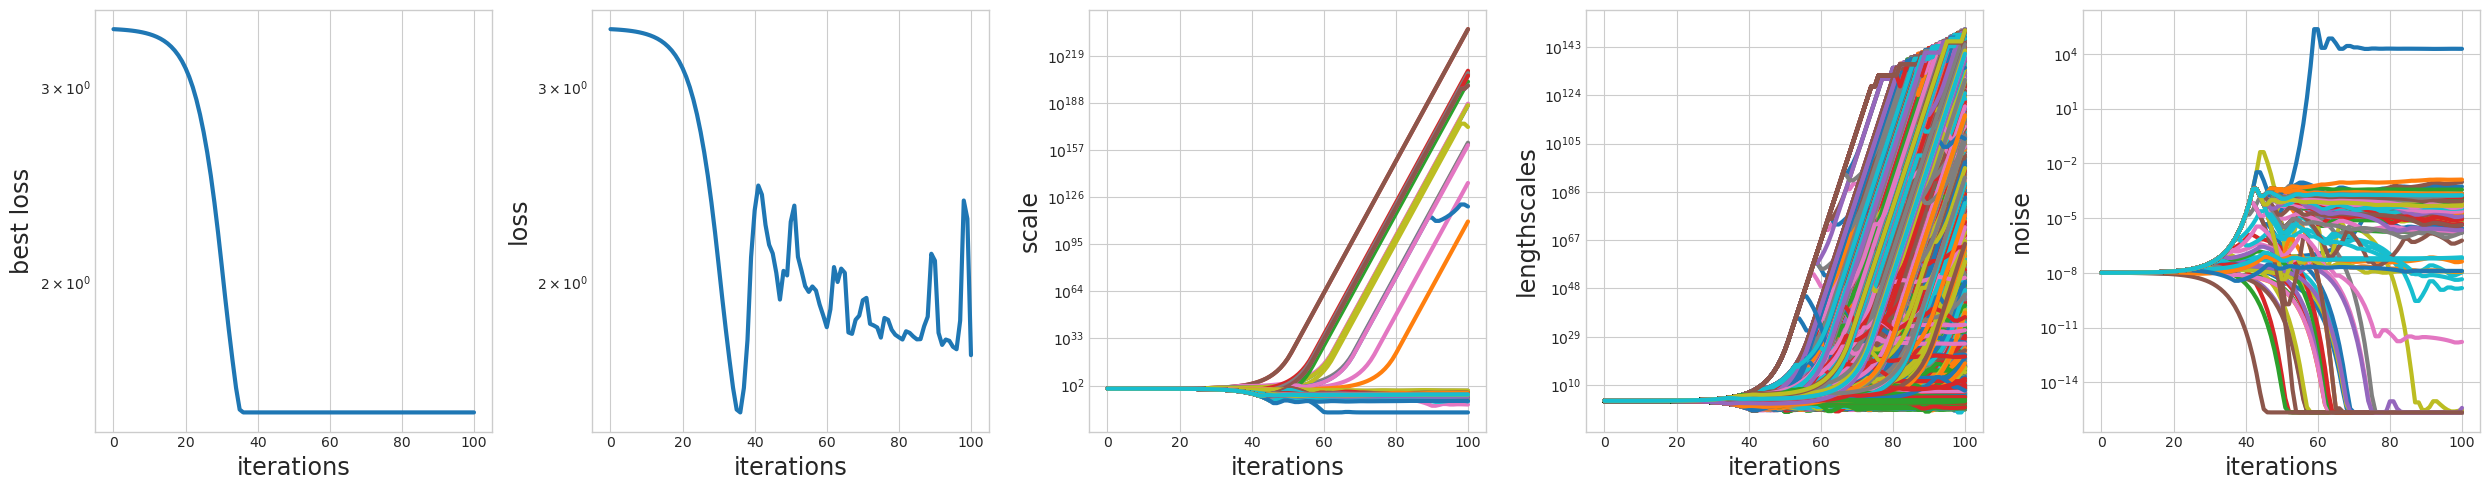

In [34]:
fastgps.plot_fastgps_fit_data(fit_data_sgp_ig,["best_loss","loss","scale","lengthscales","noise"]);

In [35]:
gp_ig_predictor_cls = Predictor(lambda w: sgp_ig.post_mean(w).T, outputs_ig_cls)
vhat_ig_gp = gp_ig_predictor_cls.forward_eval(inputs_ig_cls.w_v)
print("l2 relative error: %.2e"%(compute_l2errors(data["velocity_val"].to(DEVICE),vhat_ig_gp).mean()))

l2 relative error: 6.31e-02


## CHONKNORIS Model

### Input Data

In [36]:
class InputDataTF:
    def __init__(self, relaxation, v, w, tidxs, vidxs, updated, Midxs, normalize=False, log_relaxation=False, log_v=False):
        M = v.size(1) # total number of iterations
        assert (Midxs<(M-1)).all(), "Midxs must be less than M-1=%d"%(M-1)
        self.normalize = normalize
        self.log_relaxation = log_relaxation
        self.log_v = log_v
        assert relaxation.device==v.device==w.device==tidxs.device==vidxs.device==Midxs.device==updated.device
        _updated = updated[:,Midxs]
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        _vs = v[:,Midxs]
        vs_t = _vs[tidxs][updated_t]
        vs_v = _vs[vidxs][updated_v]
        _relaxations = relaxation[:,Midxs+1]
        relaxations_t = _relaxations[tidxs][updated_t]
        relaxations_v = _relaxations[vidxs][updated_v]
        _wavefield_full = torch.tile(w[:,None,:,:,:],(1,len(Midxs),1,1,1))
        wavefield_full_t = _wavefield_full[tidxs][updated_t]
        wavefield_full_v = _wavefield_full[vidxs][updated_v]
        if self.log_relaxation:
            relaxations_t = torch.log(relaxations_t)
            relaxations_v = torch.log(relaxations_v)
        if self.log_v:
            vs_t = torch.log(vs_t)
            vs_v = torch.log(vs_v)
        self.inputs_t = torch.cat([relaxations_t[:,None],vs_t.flatten(start_dim=1),wavefield_full_t.flatten(start_dim=1)],dim=-1)
        self.inputs_v = torch.cat([relaxations_v[:,None],vs_v.flatten(start_dim=1),wavefield_full_v.flatten(start_dim=1)],dim=-1)
        if self.normalize:
            self.inputs_t_mean = self.inputs_t.mean(0) 
            self.inputs_t_std = self.inputs_t.std(0) 
            self.inputs_t_std[self.inputs_t_std==0] = 1
            self.inputs_t = (self.inputs_t-self.inputs_t_mean)/self.inputs_t_std
            self.inputs_v = (self.inputs_v-self.inputs_t_mean)/self.inputs_t_std
    def forwards(self, relaxation, v, w):
        assert relaxation.ndim==1 and v.ndim>=2 and w.ndim>=2
        assert relaxation.shape[0]==v.shape[0]==w.shape[0]
        if self.log_relaxation:
            relaxation = torch.log(relaxation) 
        if self.log_v:
            v = torch.log(v) 
        inputs = torch.cat([relaxation[...,None],v.flatten(start_dim=1),w.flatten(start_dim=1)],dim=1)
        if self.normalize:
            inputs = (inputs-self.inputs_t_mean)/self.inputs_t_std
        return inputs
Midxs = torch.linspace(1,29,steps=15,dtype=int,device=DEVICE)
# Midxs = torch.linspace(1,19,steps=10,dtype=int,device=DEVICE)
# Midxs = torch.linspace(0,10,steps=9,dtype=int,device=DEVICE)
# Midxs = torch.linspace(0,25,steps=5,dtype=int,device=DEVICE)
print("Midxs = %s"%str(Midxs.cpu().numpy()))
print("len(Midxs) = %d"%len(Midxs))
inputs_cls = InputDataTF(
    data["relaxations"].to(DEVICE),
    data["vs"].to(DEVICE), 
    data["wavefield"].to(DEVICE),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_relaxation = True, 
    log_v = True,
)
print("inputs_cls.inputs_t.shape = %s"%str(tuple(inputs_cls.inputs_t.shape)))
print("inputs_cls.inputs_v.shape = %s"%str(tuple(inputs_cls.inputs_v.shape)))

Midxs = [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29]
len(Midxs) = 15
inputs_cls.inputs_t.shape = (11872, 7251)
inputs_cls.inputs_v.shape = (2967, 7251)


### Output Data

In [37]:
class OutputDataTF:
    def __init__(self, L, tidxs, vidxs, updated, Midxs, normalize=False, log_diag=False):
        self.normalize = normalize
        self.log_diag = log_diag 
        assert L.device==tidxs.device==vidxs.device==Midxs.device
        L = L[:,Midxs]
        _updated = updated[:,Midxs].clone()
        updated_t = _updated[tidxs]
        updated_v = _updated[vidxs]
        self.L_t = L[tidxs][updated_t].clone()
        self.L_v = L[vidxs][updated_v]
        L_t = self.L_t.clone()
        L_v = self.L_v.clone()
        if self.log_diag:
            L_t[...,Nx2r,Nx2r] = torch.log(L_t[...,Nx2r,Nx2r])
            L_v[...,Nx2r,Nx2r] = torch.log(L_v[...,Nx2r,Nx2r])
        self.outputs_t = L_t[:,lti0,lti1]
        self.outputs_v = L_v[:,lti0,lti1]
        if self.normalize:
            self.outputs_t_mean = self.outputs_t.mean(0)
            self.outputs_t_std = self.outputs_t.std(0)
            self.outputs_t_std[self.outputs_t_std==0] = 1
            self.outputs_t = (self.outputs_t-self.outputs_t_mean)/self.outputs_t_std
            self.outputs_v = (self.outputs_v-self.outputs_t_mean)/self.outputs_t_std
    def backwards(self, outputs):
        if self.normalize:
            outputs = outputs*self.outputs_t_std+self.outputs_t_mean
        L = torch.zeros(list(outputs.shape[:-1])+[Nx**2,Nx**2],device=outputs.device)
        L[...,lti0,lti1] = outputs
        if self.log_diag:
            L[...,Nx2r,Nx2r] = torch.exp(L[...,Nx2r,Nx2r])
        return L
outputs_cls = OutputDataTF(
    torch.linalg.solve_triangular(data["Linvs"].to(DEVICE),eyeNx2,upper=False),
    data["tidxs"].to(DEVICE),
    data["vidxs"].to(DEVICE),
    data["updated"].to(DEVICE),
    Midxs = Midxs,
    normalize = True, 
    log_diag = True,
)
print("outputs_cls.outputs_t.shape = %s"%str(tuple(outputs_cls.outputs_t.shape)))
print("outputs_cls.outputs_v.shape = %s"%str(tuple(outputs_cls.outputs_v.shape)))

outputs_cls.outputs_t.shape = (11872, 5050)
outputs_cls.outputs_v.shape = (2967, 5050)


### Model Prep

In [38]:
outdir_chonknoris = outdir+"/MODELS_L"
if not os.path.isdir(outdir_chonknoris): os.mkdir(outdir_chonknoris)

## GPR

In [39]:
import gc
gc.collect()
torch.cuda.empty_cache()
sgp = fastgps.StandardGP(
    qp.KernelSquaredExponential(
        d = 1+Nx*Nx+Ns*Nt*Nx,
        #shape_scale = [Nx*Nx*(1+Nx*Nx)//2,1],
        lengthscales=1+Nx*Nx+Ns*Nt*Nx,
        #shape_lengthscales=[1],
        shape_lengthscales=[1+Nx*Nx+Ns*Nt*Nx],
        torchify = True,
        device = DEVICE,
        compile_call = True,
    ),
    {"x":inputs_cls.inputs_t,"y":outputs_cls.outputs_t.T},
    noise = 1e-8,
    requires_grad_noise=True,
)
for _pname,_pval in sgp.named_parameters():
    print("%s.shape = %s"%(_pname,str(tuple(_pval.shape))))
print()
fit_data_sgp = sgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(outputs_cls.L_t,dim=(1,2)),
    #cv_weights = torch.log10(1/relaxations_t[updated_t]).to(DEVICE)**4,
    # cv_weights = torch.log10(relaxations_t[updated_t].to(DEVICE))/torch.linalg.norm(outputs_t.to(DEVICE),dim=1),
    iterations = 50,
    verbose = 1,
    store_hists = True,
    stop_crit_wait_iterations = np.inf,
    #stop_crit_improvement_threshold = 1e-1,
    #lr = 1e0,
    #optimizer=torch.optim.Rprop(sgp.parameters(),lr=1e0),#,etas=(0.5,1.2),step_sizes=(0,10)),
    #optimizer=torch.optim.Adam(sgp.parameters(),lr=1e0,amsgrad=True),#,lr=5e-2),
    )

raw_noise.shape = (1,)
kernel.raw_factor.shape = (1, 1)
kernel.raw_diag.shape = (1,)
kernel.base_kernel.raw_scale.shape = (1,)
kernel.base_kernel.raw_lengthscales.shape = (7251,)

     iter of 5.0e+01 | best loss  | loss       | term1      | term2     
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 7.32e+03   | 7.32e+03   | nan        | nan       
            1.00e+00 | 7.13e+03   | 7.13e+03   | nan        | nan       
            2.00e+00 | 6.87e+03   | 6.87e+03   | nan        | nan       
            3.00e+00 | 6.51e+03   | 6.51e+03   | nan        | nan       
            4.00e+00 | 6.06e+03   | 6.06e+03   | nan        | nan       
            5.00e+00 | 5.59e+03   | 5.59e+03   | nan        | nan       
            6.00e+00 | 5.24e+03   | 5.24e+03   | nan        | nan       
            7.00e+00 | 5.11e+03   | 5.11e+03   | nan        | nan       
            8.00e+00 | 5.03e+03   | 5.03e+03   | nan        | nan       
            9.00e

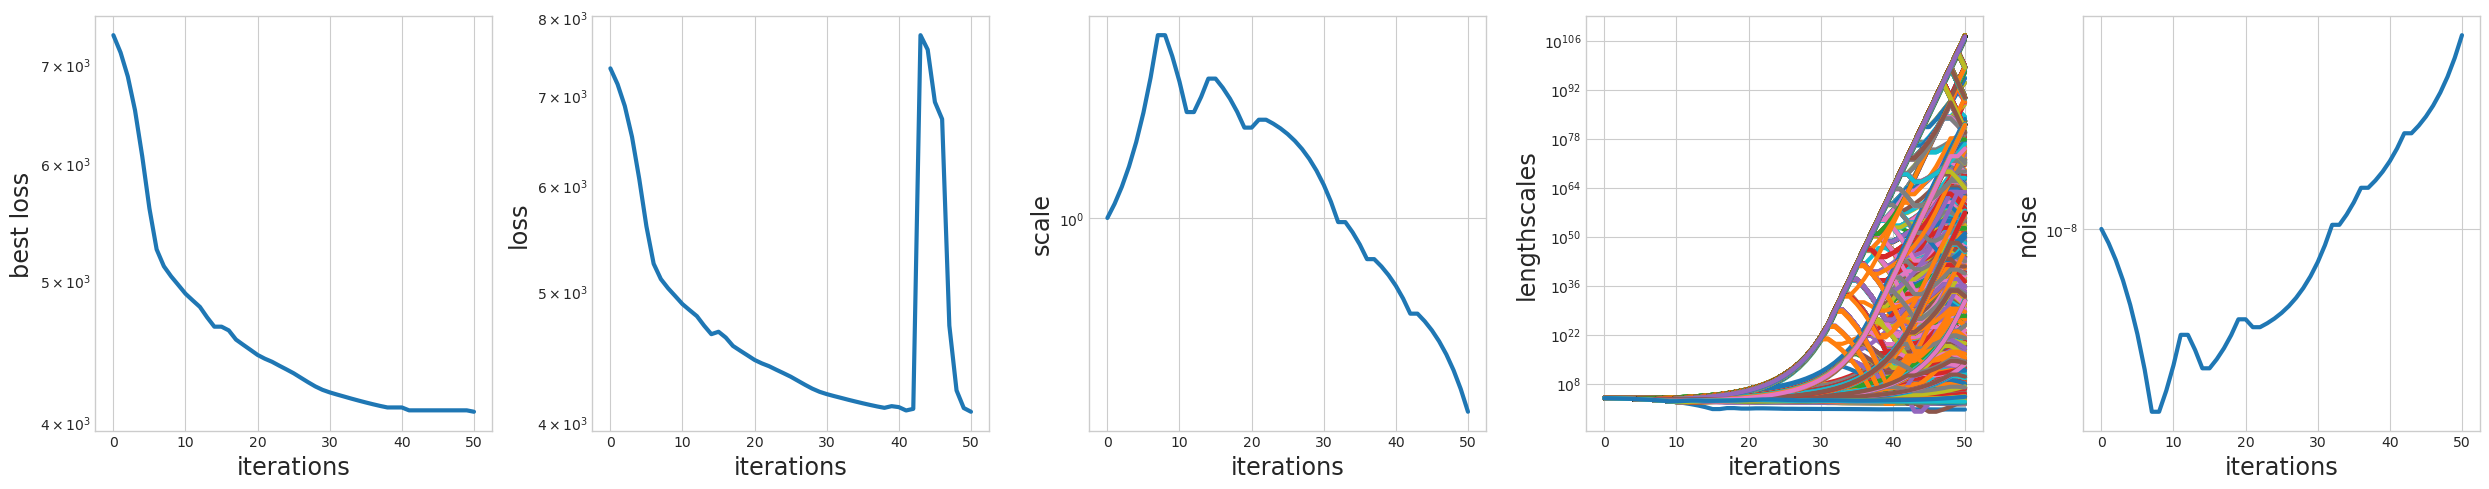

In [40]:
fastgps.plot_fastgps_fit_data(fit_data_sgp,["best_loss","loss","scale","lengthscales","noise"]);

In [41]:
gp_predictor_cls = Predictor(lambda inputs: sgp.post_mean(inputs).T, outputs_cls)
Lhat_gp = gp_predictor_cls.forward_eval(inputs_cls.inputs_v)
print("l2 relative error: %.2e"%(compute_l2errors(outputs_cls.L_v,Lhat_gp).mean()))

l2 relative error: 8.93e-02


## Inference

In [42]:
class InferenceMachine:
    def __init__(self, predictor, inputs_cls):
        self.predictor = predictor 
        self.inputs_cls = inputs_cls
    def predict(self, relaxations, v, w, JtF):
        inputs = self.inputs_cls.forwards(relaxations, v, w)
        Lhat = self.predictor.forward_eval(inputs)
        success = torch.ones(relaxations.size(0),dtype=bool,device=relaxations.device)
        delta_try = torch.cholesky_solve(JtF[success,:,None],Lhat[success],upper=False)[...,0]
        return delta_try,success
R_infer = 25
vref = data["velocity"][data["vidxs"]][:R_infer].to(DEVICE)
w = data["wavefield"][data["vidxs"]][:R_infer].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,0].to(DEVICE)
# v0 = data["vs"][data["vidxs"]][:R_infer,10].to(DEVICE)
v0 = vhat_ig_gp[:R_infer]
_,data_infer = fwi_gn_solver(p,w,v0,Thetainv_v=Thetainv_v.to(DEVICE),Thetainv_w=Thetainv_w.to(DEVICE),vref=vref,
                             predict=InferenceMachine(gp_predictor_cls, inputs_cls).predict,
                             num_newton_iter=25000,
                             relaxation=1e1,
                             lr=1,
                             wiggle_factors_relaxation=(1/2,2),
                             wiggle_factors_lr=(1/2,2),
                             range_relaxations=(0,np.inf),
                             range_lrs = (0,np.inf),
                             print_rmse_flow=False,
                             verbose = 100,
                             )
torch.save(data_infer,outdir+"/CHONKNORIS.GP.SAVE.%s.%s.pt"%(pname,vtype))

    iter of 25000  | time      | RMSE                                                             | L2 relative error                                   | relaxations                                         | lrs                                                 |
                   |           | 5%           median       mean         95%          finite %     | 5%           median       mean         95%          | 5%           median       mean         95%          | 5%           median       mean         95%          |
    -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0              | 2.62e+01  | 8.61e+00     1.28e+01     1.38e+01     2.22e+01     100.0        | 4.84e-02     6.24e-02     6.42e-02     8.61e-02     | 1.00e+01     1.00e+01     1.00e+01     1.00e+01     | 1.00e+

    100            | 2.62e+01  | 1.57e-02     1.35e-01     8.16e-01     4.26e+00     100.0        | 1.95e-02     4.08e-02     5.88e-02     1.37e-01     | 2.50e+00     1.00e+01     7.74e+24     6.57e+04     | 1.29e-02     5.00e-01     4.18e-01     1.00e+00     |
    200            | 2.63e+01  | 9.20e-03     6.51e-02     6.52e-01     4.11e+00     100.0        | 1.59e-02     3.51e-02     5.26e-02     1.24e-01     | 2.50e+00     1.00e+01     2.08e+33     2.03e+31     | 6.27e-03     2.50e-01     3.46e-01     5.00e-01     |
    300            | 2.62e+01  | 7.73e-03     4.70e-02     4.08e-01     2.98e+00     100.0        | 1.50e-02     3.27e-02     4.96e-02     1.35e-01     | 2.50e+00     1.00e+01     5.58e+41     2.66e+36     | 3.13e-02     2.50e-01     3.65e-01     5.00e-01     |
    400            | 2.64e+01  | 6.86e-03     3.89e-02     2.96e-01     1.88e+00     100.0        | 1.43e-02     3.10e-02     4.72e-02     1.38e-01     | 1.25e+00     1.00e+01     8.92e+42     6.65e+35     | 1.88e-

/data2/agsorok/DeepNewtonOperator/chonknoris/plots.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


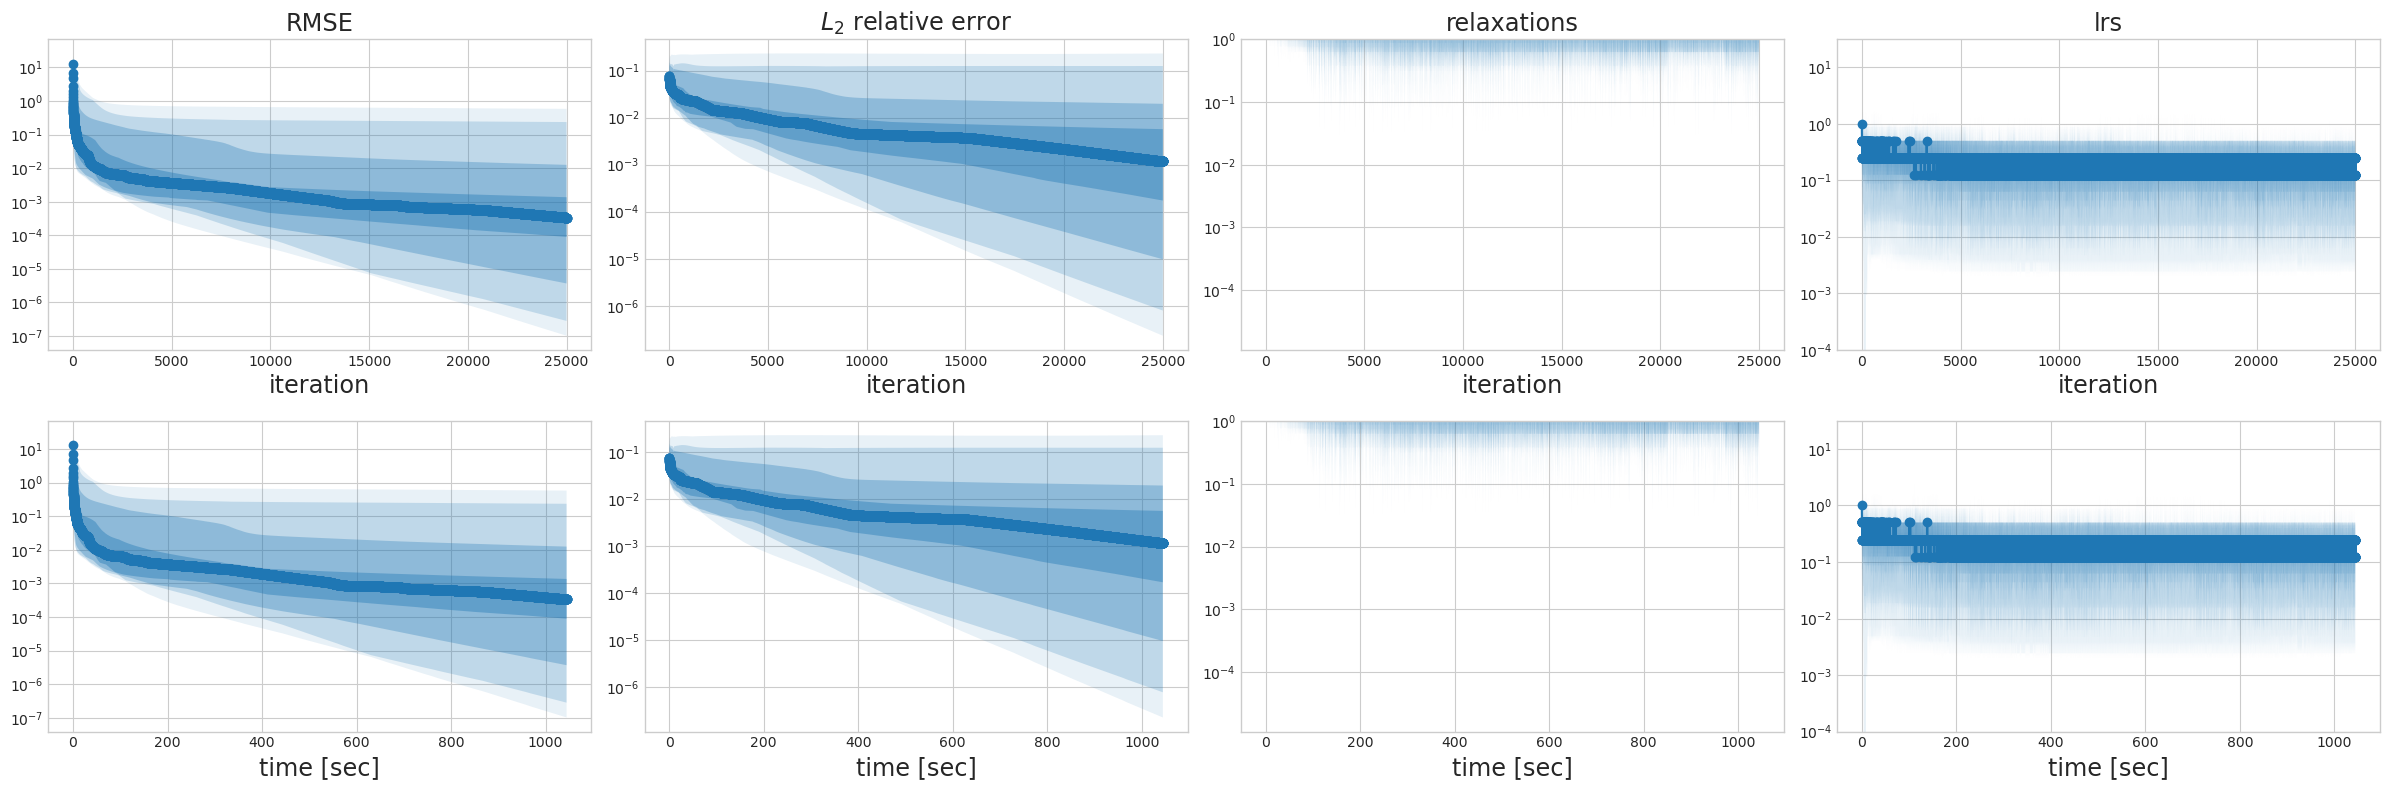

In [43]:
nnif = data_infer["rmses"].size(1) 
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [
                #(None,data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["rmses"],None)
            ],
            [
                #(None,data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["l2rerrors"],None)],
            [
                #(None,data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["relaxations"],None)],
            [
                #(None,data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                (None,data_infer["lrs"],None)],

        ],
        [
            [
                #(data["times"][:nnif].cumsum(0),data["rmses"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["rmses"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["l2rerrors"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["l2rerrors"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["relaxations"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["relaxations"],None)],
            [
                #(data["times"][:nnif].cumsum(0),data["lrs"][data["vidxs"]][:R_infer,:nnif],None),
                ((data_infer["times"]/R_infer).cumsum(0),data_infer["lrs"],None)],

        ],
    ],
    sharex = False,
    titles = [["RMSE",r"$L_2$ relative error","relaxations","lrs"],[None,None,None,None]],
    xlabels = [["iteration"],["time [sec]"]],
    xlogscale = False,
    ylogscale = True,
    # colors = COLORS,
    fsx=4,fsy=6)
for i in range(2):
    ax[i,2].set_ylim([ax[i,2].get_ylim()[0],1])
    ax[i,3].set_ylim([1e-4,ax[i,3].get_ylim()[1]])
fig.tight_layout()

tensor([0.0616, 0.0612, 0.0693, 0.0722, 0.0665])
tensor([0.1494, 0.0050, 0.0026, 0.0005, 0.0086])


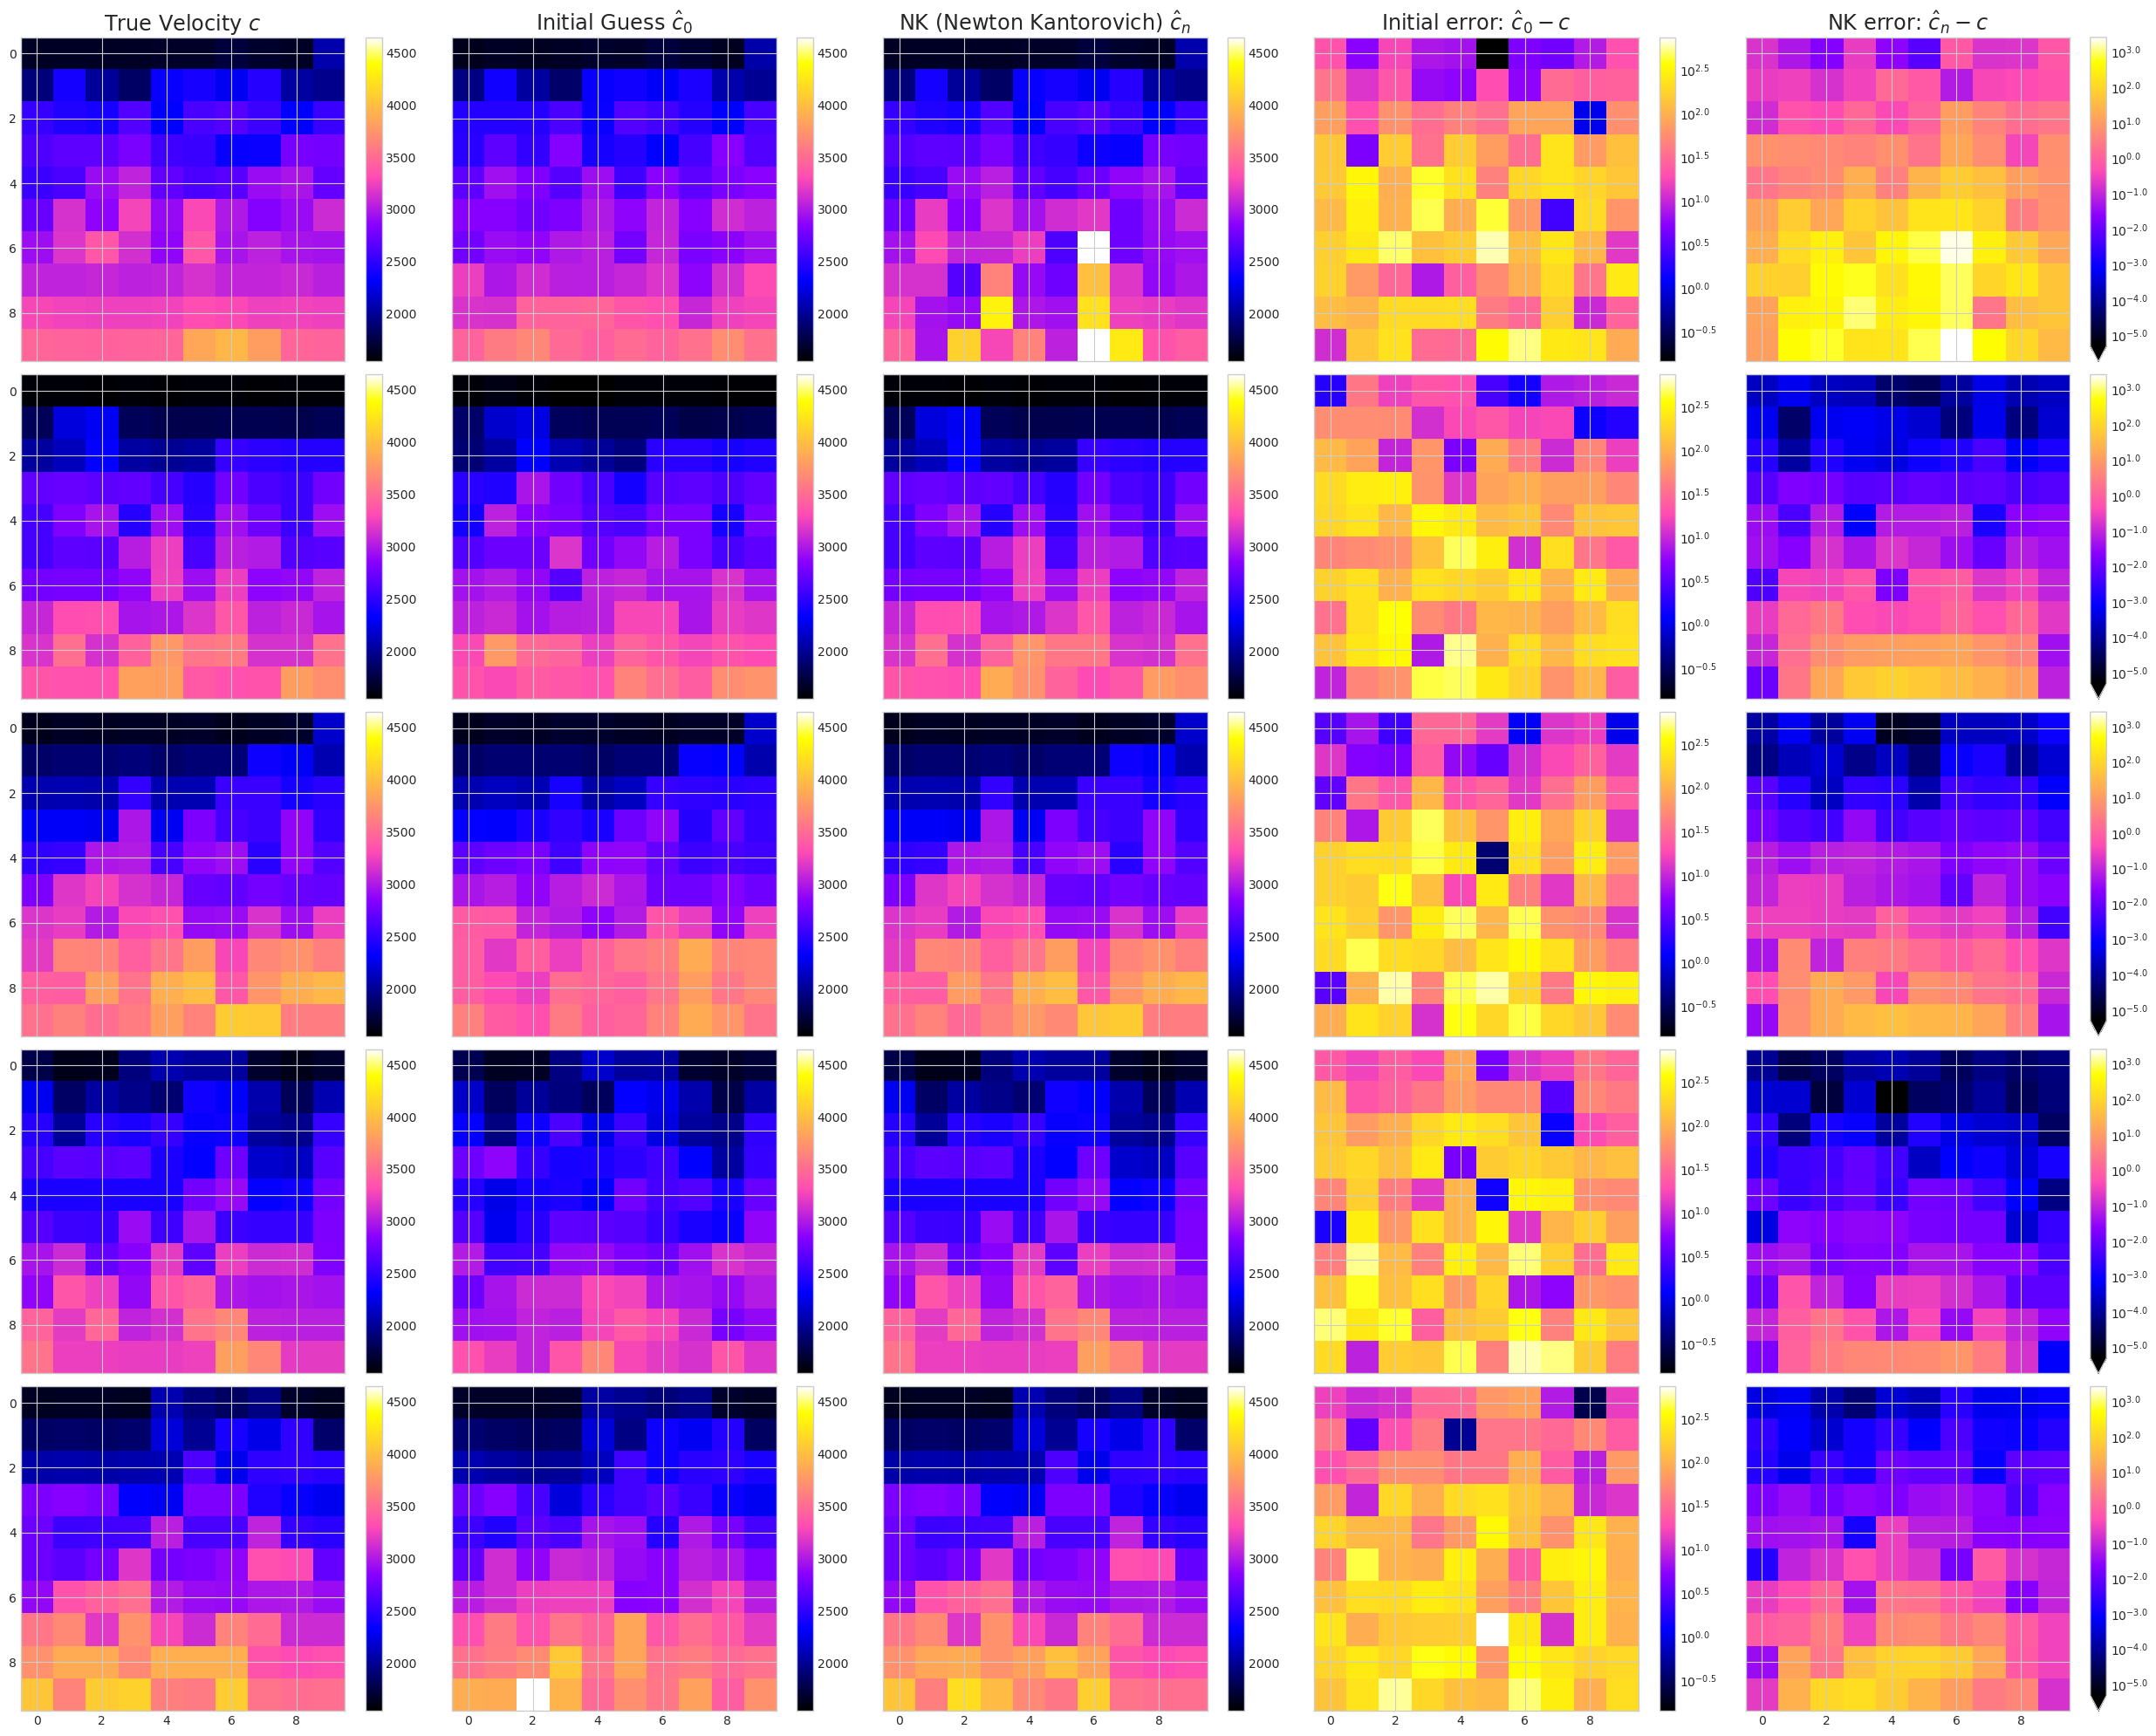

In [44]:
Rplt = 5
print(data_infer["l2rerrors"][:Rplt,0])
print(data_infer["l2rerrors"][:Rplt,-1])
plot_nk_velocities(vref.cpu()[:Rplt],data_infer["vs"][:Rplt,0].cpu(),data_infer["vs"][:Rplt,-1].cpu());

## Check for improved condition numbers

Appears that $\kappa(A) = \kappa(LL^T) =\kappa(L)^2$, but I only see this proven for the *pivoted* Cholesky decomp in https://eprints.maths.manchester.ac.uk/695/1/high87t.pdf (discussion after equation (1.4)) 

In [45]:
L_full = torch.cat([outputs_cls.L_t,outputs_cls.L_v],dim=0)
L_full.shape
Theta_full = torch.einsum("...ij,...kj->...ik",L_full,L_full)
conds_L_full = torch.linalg.cond(L_full)
conds_Theta_full = torch.linalg.cond(Theta_full)
torch.allclose(conds_Theta_full,conds_L_full**2)

True

In [46]:
inputs_all = torch.cat([inputs_cls.inputs_v,inputs_cls.inputs_t],dim=0)
Lhat_gp_full = gp_predictor_cls.forward_eval(inputs_all)
conds_Lhat_gp_full = torch.linalg.cond(Lhat_gp_full)
L2_full = torch.linalg.solve_triangular(Lhat_gp_full,L_full,upper=False)
conds_L2_full = torch.linalg.cond(L2_full)

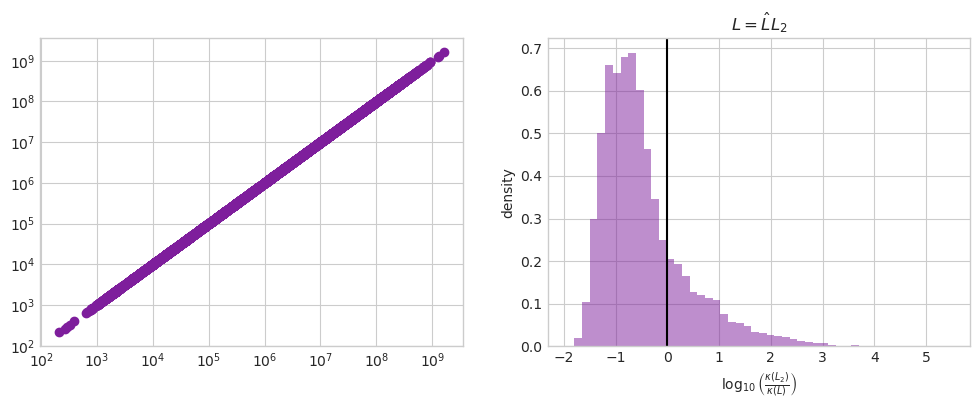

In [47]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(12,4))
ax[0].scatter(conds_Theta_full.flatten().cpu(),conds_L_full.flatten().cpu()**2,color=COLORS[0])
ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[1].hist(torch.log10(conds_L2_full/conds_L_full).flatten().cpu(),alpha=.5,bins=50,density=True,color=COLORS[0])
ax[1].axvline(x=0,color="k")
ax[1].set_xlabel(r"$\log_{10}\left(\frac{\kappa(L_2)}{\kappa(L)}\right)$")
ax[1].set_ylabel("density")
ax[1].set_title(r"$L = \hat{L} L_2$");